# Task 07 - Feature Importance (Bước 1)

Notebook này là **Bước 1** trong kế hoạch cải tiến model của week_3:
1. **Feature importance** (notebook này) - tạo mốc tham chiếu trên model baseline V1.
2. Thêm feature mới (V2/V3).
3. Thử các cách xử lý imbalance (under/over-sampling).
4. Finetune lại model mới.

Mục tiêu của notebook:
- Load lại 2 model LightGBM đã train ở week_3 (classifier + regressor) cùng metadata tiền xử lý.
- Dựng lại **validation set** (split theo thời gian giống lúc train) bằng pandas, không cần Spark.
- Đo **built-in importance** (`gain` + `split`) và **permutation importance** (đáng tin hơn vì đo trên dữ liệu hold-out).
- Lưu bảng importance + biểu đồ để dùng làm mốc so sánh cho các bước sau.

> Lưu ý: chỉ load model + transform validation theo đúng rule đã fit từ train. Không fit lại gì từ validation.

## 0. Setup & load metadata

In [1]:
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=UserWarning)

# week_4/ -> project root g:/ds
NB_DIR = Path.cwd().resolve()
PROJECT_ROOT = NB_DIR if (NB_DIR / "data_pyspark_parquet").exists() else NB_DIR.parent
if not (PROJECT_ROOT / "data_pyspark_parquet").exists():
    PROJECT_ROOT = Path(r"g:/ds")

PARQUET_DIR = PROJECT_ROOT / "data_pyspark_parquet"
TRAIN_FEATURE_PATH = PARQUET_DIR / "train_user_session_features_30d"
MODELS_DIR = PROJECT_ROOT / "models"

PREPROCESSING_METADATA_PATH = MODELS_DIR / "lgbm_modeling_preprocessing_30d.json"
PURCHASE_CLASSIFIER_MODEL_PATH = MODELS_DIR / "lgbm_purchase_classifier_30d.pkl"
REVENUE_REGRESSOR_MODEL_PATH = MODELS_DIR / "lgbm_revenue_regressor_30d.pkl"

OUTPUT_DIR = NB_DIR / "feature_importance_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

with PREPROCESSING_METADATA_PATH.open(encoding="utf-8") as f:
    meta = json.load(f)

FEATURE_COLUMNS = meta["feature_columns"]
NUMERIC_FEATURES = meta["numeric_features"]
CATEGORICAL_FEATURES = meta["categorical_features"]
BINARY_FEATURES = meta["binary_features"]
CATEGORY_LEVELS = meta["category_levels_fit_from_train_split"]
CLASSIFICATION_LABEL = meta["classification_label"]
REVENUE_LABEL = meta["revenue_label"]
LOG_REVENUE_LABEL = meta["log_revenue_label"]
SELECTED_THRESHOLD = meta["selected_threshold"]
SPLIT_CONFIG = meta["train_validation_split_config"]

print("Project root:", PROJECT_ROOT)
print("Feature count:", len(FEATURE_COLUMNS))
print("Categorical:", CATEGORICAL_FEATURES)
print("Validation window:", SPLIT_CONFIG["validation_start_inclusive"], "->", SPLIT_CONFIG["validation_end_inclusive"])
print("Output dir:", OUTPUT_DIR)

Project root: G:\ds
Feature count: 27
Categorical: ['channelGrouping_model', 'traffic_channel_type_model', 'device_category_model', 'geo_country_model']
Validation window: 2018-03-01 -> 2018-03-31
Output dir: G:\ds\week_4\feature_importance_outputs


## 1. Dựng lại validation set bằng pandas

Đọc parquet feature table (do Spark ghi) bằng pyarrow, lọc `has_full_30d_label_window == 1`, rồi
cắt theo cửa sổ thời gian validation **giống hệt** lúc train (2018-03-01 .. 2018-03-31).
Permutation importance sẽ đo trên chính validation set này.

In [2]:
KEY_COLUMNS = ["fullVisitorId", "visit_id"]
NEEDED_COLUMNS = list(dict.fromkeys(
    KEY_COLUMNS + ["session_date", "has_full_30d_label_window"]
    + FEATURE_COLUMNS + [CLASSIFICATION_LABEL, REVENUE_LABEL]
))

raw_pdf = pd.read_parquet(TRAIN_FEATURE_PATH, columns=NEEDED_COLUMNS, engine="pyarrow")
print("Raw rows:", len(raw_pdf))

full_window = raw_pdf[raw_pdf["has_full_30d_label_window"] == 1].copy()
session_date = pd.to_datetime(full_window["session_date"]).dt.date

val_start = pd.to_datetime(SPLIT_CONFIG["validation_start_inclusive"]).date()
val_end = pd.to_datetime(SPLIT_CONFIG["validation_end_inclusive"]).date()
validation_pdf = full_window[(session_date >= val_start) & (session_date <= val_end)].copy()

print("Validation rows:", len(validation_pdf))
print("Positive rate (cls):", round(validation_pdf[CLASSIFICATION_LABEL].mean() * 100, 3), "%")
print("Positive revenue rows:", int((validation_pdf[REVENUE_LABEL] > 0).sum()))

Raw rows: 1706613
Validation rows: 93998
Positive rate (cls): 1.183 %
Positive revenue rows: 1084


### 1.1 Áp dtype giống lúc train (numeric float64 / binary int8 / categorical theo level đã fit)

In [3]:
def apply_lightgbm_dtypes(pdf):
    out = pdf.copy()
    for col in NUMERIC_FEATURES:
        out[col] = pd.to_numeric(out[col], errors="coerce").astype("float64")
    for col in BINARY_FEATURES:
        out[col] = pd.to_numeric(out[col], errors="coerce").astype("int8")
    for col in CATEGORICAL_FEATURES:
        out[col] = pd.Categorical(out[col].astype(str), categories=CATEGORY_LEVELS[col])
    out[CLASSIFICATION_LABEL] = pd.to_numeric(out[CLASSIFICATION_LABEL], errors="raise").astype("int8")
    out[REVENUE_LABEL] = pd.to_numeric(out[REVENUE_LABEL], errors="raise").astype("float64")
    out[LOG_REVENUE_LABEL] = np.log1p(out[REVENUE_LABEL])
    return out


validation_lgbm = apply_lightgbm_dtypes(validation_pdf)

# Classification: toàn bộ validation rows
X_valid_cls = validation_lgbm[FEATURE_COLUMNS]
y_valid_cls = validation_lgbm[CLASSIFICATION_LABEL]

# Conditional regression: chỉ các row có revenue > 0
pos_mask = validation_lgbm[REVENUE_LABEL] > 0
X_valid_reg = validation_lgbm.loc[pos_mask, FEATURE_COLUMNS]
y_valid_reg_log = validation_lgbm.loc[pos_mask, LOG_REVENUE_LABEL]

print("X_valid_cls:", X_valid_cls.shape, "| X_valid_reg:", X_valid_reg.shape)

X_valid_cls: (93998, 27) | X_valid_reg: (1084, 27)


## 2. Load 2 model đã train

In [4]:
import pickle

with PURCHASE_CLASSIFIER_MODEL_PATH.open("rb") as f:
    purchase_classifier = pickle.load(f)
with REVENUE_REGRESSOR_MODEL_PATH.open("rb") as f:
    revenue_regressor = pickle.load(f)

# Kiểm tra thứ tự feature của model khớp với FEATURE_COLUMNS
assert list(purchase_classifier.feature_name_) == FEATURE_COLUMNS, "Classifier feature order mismatch"
assert list(revenue_regressor.feature_name_) == FEATURE_COLUMNS, "Regressor feature order mismatch"
print("Loaded classifier & regressor; feature order khớp metadata.")

Loaded classifier & regressor; feature order khớp metadata.


## 3. Built-in importance (gain + split)

LightGBM cho 2 loại importance:
- **gain**: tổng mức giảm loss khi feature được dùng để split -> phản ánh "đóng góp" thực sự.
- **split**: số lần feature được dùng để split -> dễ thiên vị về feature high-cardinality.

Ta lấy cả hai cho từng model.

In [5]:
def builtin_importance_frame(model, name):
    gain = model.booster_.feature_importance(importance_type="gain")
    split = model.booster_.feature_importance(importance_type="split")
    df = pd.DataFrame({
        "feature": model.feature_name_,
        f"{name}_gain": gain,
        f"{name}_split": split,
    })
    df[f"{name}_gain_pct"] = df[f"{name}_gain"] / df[f"{name}_gain"].sum() * 100
    return df


cls_builtin = builtin_importance_frame(purchase_classifier, "cls")
reg_builtin = builtin_importance_frame(revenue_regressor, "reg")

builtin_importance = cls_builtin.merge(reg_builtin, on="feature", how="outer")
builtin_importance = builtin_importance.sort_values("cls_gain", ascending=False).reset_index(drop=True)
builtin_importance.head(30)

,feature,cls_gain,cls_split,cls_gain_pct,reg_gain,reg_split,reg_gain_pct
0,visit_number,1.181407e+07,214,39.276914,3122.772402,55,6.248486
1,totals_hits,7.410810e+06,334,24.637887,1291.121800,35,2.583460
2,device_category_model,3.388218e+06,136,11.264428,2047.995384,19,4.097919
3,channelGrouping_model,2.298696e+06,251,7.642216,1685.654617,46,3.372897
4,traffic_channel_type_model,1.263512e+06,165,4.200657,96.426901,5,0.192945
5,geo_country_model,1.024185e+06,759,3.404994,1012.732896,20,2.026420
6,has_referral_path,7.473772e+05,32,2.484721,239.420301,9,0.479066
7,user_days_since_previous_purchase,4.364552e+05,88,1.451033,810.361150,28,1.621485
8,user_previous_purchase_count,2.105415e+05,38,0.699964,1084.948066,34,2.170918
9,totals_pageviews,1.723589e+05,251,0.573022,331.765442,11,0.663843


### 3.1 Biểu đồ built-in gain (top 20)

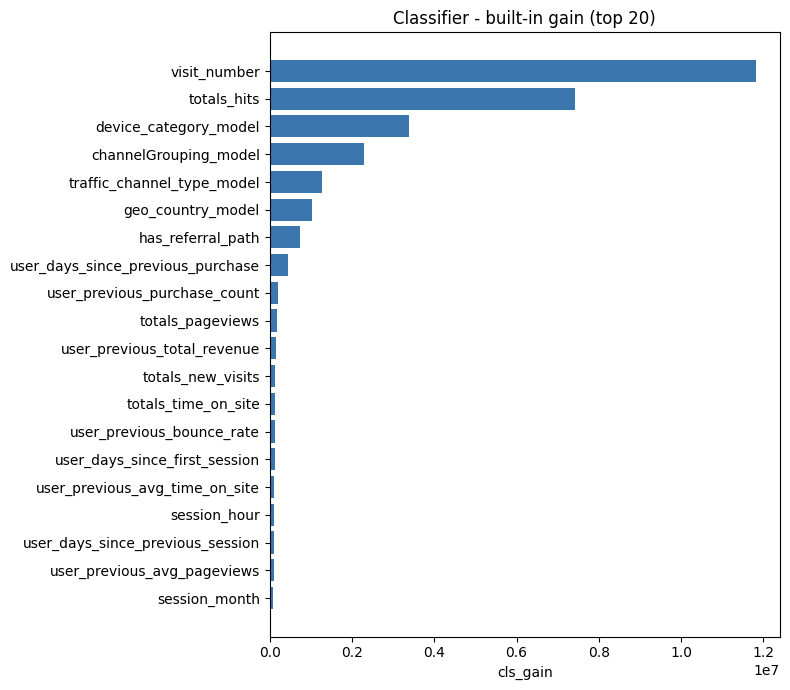

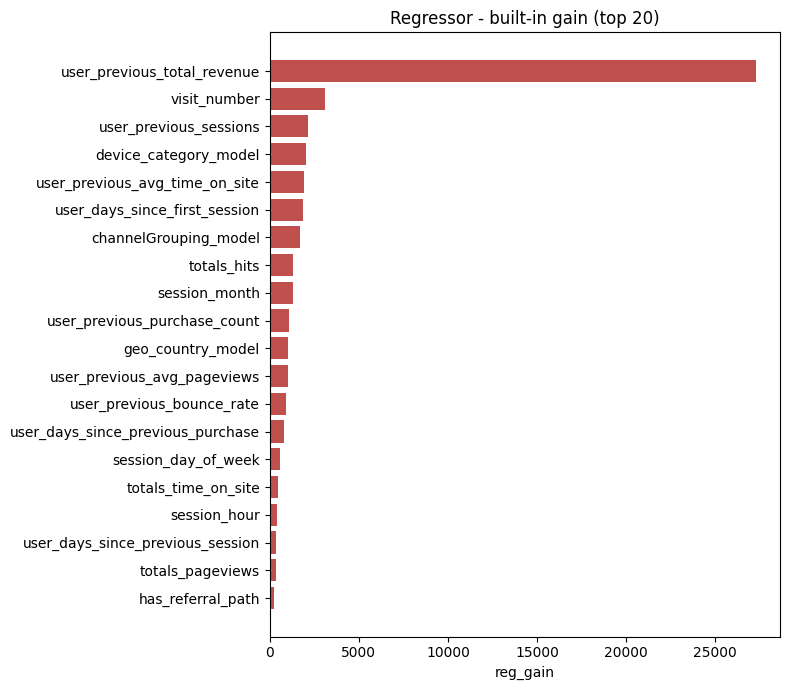

In [6]:
def plot_top(df, value_col, title, color, fname):
    top = df.sort_values(value_col, ascending=False).head(20).iloc[::-1]
    fig, ax = plt.subplots(figsize=(8, 7))
    ax.barh(top["feature"], top[value_col], color=color)
    ax.set_title(title)
    ax.set_xlabel(value_col)
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / fname, dpi=120)
    plt.show()


plot_top(builtin_importance, "cls_gain", "Classifier - built-in gain (top 20)", "#3b76af", "cls_builtin_gain_top20.png")
plot_top(builtin_importance, "reg_gain", "Regressor - built-in gain (top 20)", "#c0504d", "reg_builtin_gain_top20.png")

## 4. Permutation importance (trên validation - đáng tin hơn)

Built-in gain bị thiên vị về feature high-cardinality (vd `geo_country_model`). Permutation importance đo
**mức tụt metric** khi xáo trộn ngẫu nhiên 1 feature trên dữ liệu hold-out -> phản ánh đóng góp thật vào khả năng dự đoán.

- Classifier: scoring = **average_precision** (PR-AUC) - phù hợp dữ liệu mất cân bằng.
- Regressor: scoring = **neg_root_mean_squared_error** trên log-revenue (chỉ positive rows).

`importances_mean` càng lớn = feature càng quan trọng (xáo trộn nó làm metric tụt nhiều).

In [7]:
from sklearn.inspection import permutation_importance

PERM_N_REPEATS = 10
PERM_SEED = 42


def permutation_frame(model, X, y, scoring, name):
    result = permutation_importance(
        model, X, y,
        scoring=scoring,
        n_repeats=PERM_N_REPEATS,
        random_state=PERM_SEED,
        n_jobs=-1,
    )
    df = pd.DataFrame({
        "feature": list(X.columns),
        f"{name}_perm_mean": result.importances_mean,
        f"{name}_perm_std": result.importances_std,
    })
    return df.sort_values(f"{name}_perm_mean", ascending=False).reset_index(drop=True)


cls_perm = permutation_frame(purchase_classifier, X_valid_cls, y_valid_cls, "average_precision", "cls")
print("Classifier permutation importance (PR-AUC drop) - top 15:")
cls_perm.head(15)

Classifier permutation importance (PR-AUC drop) - top 15:


,feature,cls_perm_mean,cls_perm_std
0,visit_number,0.077325,0.001016
1,geo_country_model,0.055129,0.003083
2,totals_new_visits,0.042178,0.002004
3,has_referral_path,0.040166,0.001505
4,channelGrouping_model,0.039447,0.002469
5,totals_hits,0.034204,0.001874
6,traffic_channel_type_model,0.026061,0.002165
7,device_category_model,0.023662,0.002848
8,user_previous_avg_pageviews,0.020049,0.001860
9,user_previous_total_revenue,0.018208,0.000760


In [8]:
reg_perm = permutation_frame(
    revenue_regressor, X_valid_reg, y_valid_reg_log,
    "neg_root_mean_squared_error", "reg",
)
print("Regressor permutation importance (RMSE-log drop) - top 15:")
reg_perm.head(15)

Regressor permutation importance (RMSE-log drop) - top 15:


,feature,reg_perm_mean,reg_perm_std
0,user_previous_total_revenue,0.055753,0.006319
1,user_previous_purchase_count,0.016624,0.001089
2,device_category_model,0.012149,0.002608
3,totals_hits,0.009049,0.002230
4,session_hour,0.005039,0.001057
5,user_days_since_previous_session,0.004207,0.000872
6,session_day_of_week,0.003879,0.001117
7,user_days_since_previous_purchase,0.003385,0.001908
8,visit_number,0.002807,0.001604
9,user_days_since_first_session,0.002768,0.002579


### 4.1 Biểu đồ permutation importance (top 20)

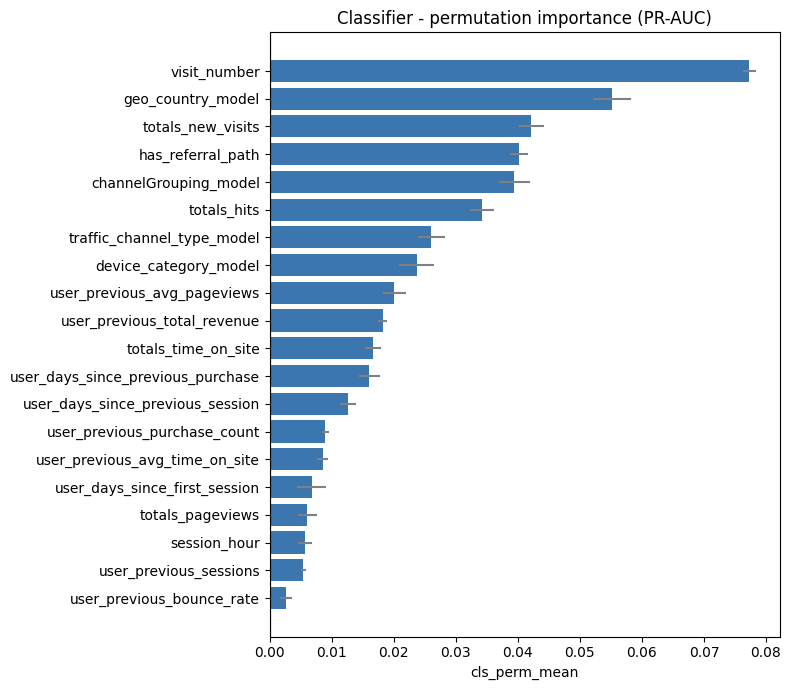

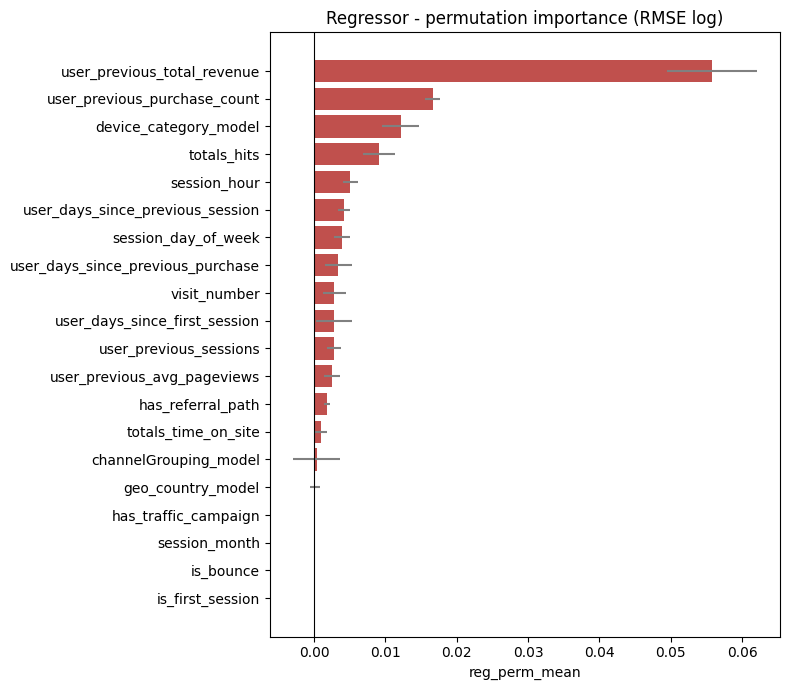

In [9]:
def plot_perm(df, mean_col, std_col, title, color, fname):
    top = df.sort_values(mean_col, ascending=False).head(20).iloc[::-1]
    fig, ax = plt.subplots(figsize=(8, 7))
    ax.barh(top["feature"], top[mean_col], xerr=top[std_col], color=color, ecolor="gray")
    ax.set_title(title)
    ax.set_xlabel(mean_col)
    ax.axvline(0, color="black", linewidth=0.8)
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / fname, dpi=120)
    plt.show()


plot_perm(cls_perm, "cls_perm_mean", "cls_perm_std", "Classifier - permutation importance (PR-AUC)", "#3b76af", "cls_perm_top20.png")
plot_perm(reg_perm, "reg_perm_mean", "reg_perm_std", "Regressor - permutation importance (RMSE log)", "#c0504d", "reg_perm_top20.png")

## 5. Tổng hợp & lưu kết quả

Gộp built-in gain + permutation thành một bảng, kèm rank của từng phương pháp để dễ đối chiếu
feature nào "yếu" (gain thấp **và** permutation ~0 -> ứng viên loại bỏ ở Bước 2).

In [10]:
summary = (
    builtin_importance[["feature", "cls_gain_pct", "reg_gain_pct"]]
    .merge(cls_perm[["feature", "cls_perm_mean"]], on="feature", how="left")
    .merge(reg_perm[["feature", "reg_perm_mean"]], on="feature", how="left")
)
summary["cls_gain_rank"] = summary["cls_gain_pct"].rank(ascending=False).astype(int)
summary["cls_perm_rank"] = summary["cls_perm_mean"].rank(ascending=False).astype(int)
summary = summary.sort_values("cls_perm_mean", ascending=False).reset_index(drop=True)

# Ứng viên feature yếu cho classifier: permutation importance <= 0 (xáo trộn không làm tụt PR-AUC)
weak_for_cls = summary.loc[summary["cls_perm_mean"] <= 0, "feature"].tolist()

builtin_importance.to_csv(OUTPUT_DIR / "builtin_importance.csv", index=False)
cls_perm.to_csv(OUTPUT_DIR / "classifier_permutation_importance.csv", index=False)
reg_perm.to_csv(OUTPUT_DIR / "regressor_permutation_importance.csv", index=False)
summary.to_csv(OUTPUT_DIR / "feature_importance_summary.csv", index=False)

with (OUTPUT_DIR / "weak_feature_candidates.json").open("w", encoding="utf-8") as f:
    json.dump({
        "validation_rows": int(len(validation_lgbm)),
        "feature_count": len(FEATURE_COLUMNS),
        "weak_for_classifier_perm_le_0": weak_for_cls,
    }, f, ensure_ascii=False, indent=2)

print("Saved importance tables & plots to:", OUTPUT_DIR)
print("Ứng viên feature yếu cho classifier (perm <= 0):", weak_for_cls)
summary

Saved importance tables & plots to: G:\ds\week_4\feature_importance_outputs
Ứng viên feature yếu cho classifier (perm <= 0): ['session_month', 'is_first_session', 'is_bounce', 'has_gclid', 'has_traffic_campaign', 'has_previous_purchase']


,feature,cls_gain_pct,reg_gain_pct,cls_perm_mean,reg_perm_mean,cls_gain_rank,cls_perm_rank
0,visit_number,39.276914,6.248486,0.077325,0.002807,1,1
1,geo_country_model,3.404994,2.026420,0.055129,0.000116,6,2
2,totals_new_visits,0.458767,0.083275,0.042178,-0.000248,12,3
3,has_referral_path,2.484721,0.479066,0.040166,0.001813,7,4
4,channelGrouping_model,7.642216,3.372897,0.039447,0.000353,4,5
5,totals_hits,24.637887,2.583460,0.034204,0.009049,2,6
6,traffic_channel_type_model,4.200657,0.192945,0.026061,-0.000193,5,7
7,device_category_model,11.264428,4.097919,0.023662,0.012149,3,8
8,user_previous_avg_pageviews,0.357170,2.014971,0.020049,0.002534,19,9
9,user_previous_total_revenue,0.478263,54.581813,0.018208,0.055753,11,10


## 6. Nhận xét & bước tiếp theo

Cách đọc kết quả:
- Feature nằm **top cả gain lẫn permutation** -> lõi của model, giữ chắc.
- Feature **gain cao nhưng permutation ~0** -> có thể chỉ đang overfit/high-cardinality, cân nhắc.
- Feature **gain thấp và permutation <= 0** (xem `weak_feature_candidates.json`) -> ứng viên loại bỏ ở Bước 2.

Đây là **mốc tham chiếu**. Sang **Bước 2** (thêm feature V2/V3) và **Bước 3** (under/over-sampling),
mỗi lần train lại sẽ so PR-AUC của classifier với baseline này để biết thay đổi có thực sự cải thiện không.